In [38]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Loading dataset 
df = pd.read_csv("retail_sales.csv",
                 parse_dates=['Date'])

# Adding additional date-related features
df['Order Year'] = df['Date'].dt.year
df['Order Month'] = df['Date'].dt.month
df['Order Day'] = df['Date'].dt.day_of_week

In [40]:
# Understanding data to drive features
print("Dataset shape(rows, columns) is", df.shape)
print("\nDataset column types are \n", df.dtypes)


Dataset shape(rows, columns) is (1825, 9)

Dataset column types are 
 Date           datetime64[us]
Category                  str
Sales                 float64
Quantity              float64
Profit                float64
Region                    str
Order Year              int32
Order Month             int32
Order Day               int32
dtype: object


In [41]:
# Displaying data head
print(df.head())

        Date     Category        Sales  Quantity      Profit Region  \
0 2023-01-01  Electronics  1149.014246      11.0  383.664245  North   
1 2023-01-01     Clothing   958.520710       7.0  224.054049   East   
2 2023-01-01   Home Goods  1473.763845       2.0  466.593090  South   
3 2023-01-01       Sports  1230.230419       6.0  123.310460   West   
4 2023-01-01         NaN?   828.585950      12.0   88.591355   East   

   Order Year  Order Month  Order Day  
0        2023            1          6  
1        2023            1          6  
2        2023            1          6  
3        2023            1          6  
4        2023            1          6  


In [42]:
# Converting "Category" and "Region" columns to categories for better manipulation
df['Category'] = df['Category'].astype('category')
df['Region'] = df['Region'].astype('category')

print(df.dtypes)
print("\nConverted to categories successfully")

Date           datetime64[us]
Category             category
Sales                 float64
Quantity              float64
Profit                float64
Region               category
Order Year              int32
Order Month             int32
Order Day               int32
dtype: object

Converted to categories successfully


In [43]:
# Checking for missing values 
df.isna().sum()

Date           0
Category       4
Sales          2
Quantity       5
Profit         0
Region         5
Order Year     0
Order Month    0
Order Day      0
dtype: int64

In [44]:
# Handling missing values
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])

df.isna().sum()

Date           0
Category       0
Sales          0
Quantity       0
Profit         0
Region         0
Order Year     0
Order Month    0
Order Day      0
dtype: int64

In [45]:
# Summary Statistics
df.describe()

,Date,Sales,Quantity,Profit,Order Year,Order Month,Order Day
count,1825,1825.000000,1825.000000,1825.000000,1825.0,1825.000000,1825.000000
mean,2023-07-02 00:00:00,980.501573,10.053699,248.696130,2023.0,6.526027,3.008219
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,2023.0,1.000000,0.000000
25%,2023-04-02 00:00:00,784.267165,5.000000,156.916498,2023.0,4.000000,1.000000
50%,2023-07-02 00:00:00,997.725134,10.000000,229.344557,2023.0,7.000000,3.000000
75%,2023-10-01 00:00:00,1208.163533,15.000000,324.867847,2023.0,10.000000,5.000000
max,2023-12-31 00:00:00,1888.932537,19.000000,703.228418,2023.0,12.000000,6.000000
std,NaN,336.572425,5.507806,118.159627,0.0,3.448796,2.003954


In [46]:
# Checking Profit against Category
print("Skewness of Profit column: ", df['Profit'].skew())
df.groupby('Category')['Profit'].describe()

Skewness of Profit column:  0.6702121466996879


,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Books,364.0,253.583660,117.922429,22.157708,166.394659,235.483626,324.232402,652.843041
Clothing,369.0,246.312838,118.959387,8.140877,149.253555,225.271072,334.726110,649.168113
Electronics,361.0,250.525479,120.134380,0.000000,157.754976,226.479496,317.128339,703.228418
Home Goods,364.0,240.241264,111.652827,0.000000,156.745914,219.101295,305.646907,608.800018
NaN?,1.0,88.591355,NaN,88.591355,88.591355,88.591355,88.591355,88.591355
Nan,1.0,253.433301,NaN,253.433301,253.433301,253.433301,253.433301,253.433301
Null,1.0,381.784578,NaN,381.784578,381.784578,381.784578,381.784578,381.784578
Sports,364.0,252.926431,121.988465,21.368432,155.847708,237.692829,328.592851,624.033248


In [47]:
# Dropping rows with values NaN?, Nan, Null
df_non_null = df.replace(['NaN?', 'Nan', 'Null', ' '], np.nan)
df_non_null.dropna()


,Date,Category,Sales,Quantity,Profit,Region,Order Year,Order Month,Order Day
0,2023-01-01,Electronics,1149.014246,11.0,383.664245,North,2023,1,6
1,2023-01-01,Clothing,958.520710,7.0,224.054049,East,2023,1,6
2,2023-01-01,Home Goods,1473.763845,2.0,466.593090,South,2023,1,6
3,2023-01-01,Sports,1230.230419,6.0,123.310460,West,2023,1,6
5,2023-01-02,Electronics,722.775149,10.0,82.396149,West,2023,1,0
...,...,...,...,...,...,...,...,...,...
1820,2023-12-31,Electronics,1132.749004,14.0,353.464221,West,2023,12,6
1821,2023-12-31,Clothing,679.261971,8.0,183.860200,North,2023,12,6
1822,2023-12-31,Home Goods,1193.733728,10.0,359.010938,South,2023,12,6
1823,2023-12-31,Sports,1076.118706,17.0,259.570916,North,2023,12,6


In [48]:
# checking profit against category after dropping null categories
df_non_null.groupby('Category')['Profit'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Books,364.0,253.583660,117.922429,22.157708,166.394659,235.483626,324.232402,652.843041
Clothing,369.0,246.312838,118.959387,8.140877,149.253555,225.271072,334.726110,649.168113
Electronics,361.0,250.525479,120.134380,0.000000,157.754976,226.479496,317.128339,703.228418
Home Goods,364.0,240.241264,111.652827,0.000000,156.745914,219.101295,305.646907,608.800018
Sports,364.0,252.926431,121.988465,21.368432,155.847708,237.692829,328.592851,624.033248


In [49]:
# Checking for zero sales with non-zero profit and item quantity
weird = df_non_null[(df_non_null['Sales']==0)& (df_non_null['Profit']!=0) & (df_non_null['Quantity'] != 0)]

print(weird['Profit'].describe())
print("\n", weird['Category'].value_counts())
print("\n", weird['Date'].dt.month.value_counts())

count     43.000000
mean     281.088945
std      114.473293
min       92.274782
25%      182.518431
50%      270.577388
75%      374.876206
max      497.017998
Name: Profit, dtype: float64

 Category
Electronics    10
Sports         10
Home Goods      9
Clothing        8
Books           6
NaN?            0
Nan             0
Null            0
Name: count, dtype: int64

 Date
4    15
2     9
3     9
1     6
5     4
Name: count, dtype: int64


Since profit with zero sales is positive. Therefore, it's an error in dataset, as we can't make profit with zero sales. In this case, dropping these rows will not bias results. 

In [50]:
# Dropping zero-sale columns
clear_df = df_non_null[~((df_non_null['Sales']==0)& (df_non_null['Profit']!=0) & (df_non_null['Quantity'] != 0))]
print(clear_df.describe())

                             Date        Sales     Quantity       Profit  \
count                        1782  1782.000000  1782.000000  1782.000000   
mean   2023-07-04 13:37:46.666666  1004.161263    10.094837   247.914485   
min           2023-01-01 00:00:00     0.000000     0.000000     0.000000   
25%           2023-04-05 00:00:00   802.432623     5.000000   156.265718   
50%           2023-07-06 00:00:00  1005.479158    10.000000   228.057049   
75%           2023-10-03 00:00:00  1212.445153    15.000000   322.496737   
max           2023-12-31 00:00:00  1888.932537    19.000000   703.228418   
std                           NaN   303.717863     5.507229   118.168586   

       Order Year  Order Month    Order Day  
count      1782.0  1782.000000  1782.000000  
mean       2023.0     6.609989     3.001684  
min        2023.0     1.000000     0.000000  
25%        2023.0     4.000000     1.000000  
50%        2023.0     7.000000     3.000000  
75%        2023.0    10.000000     5.00

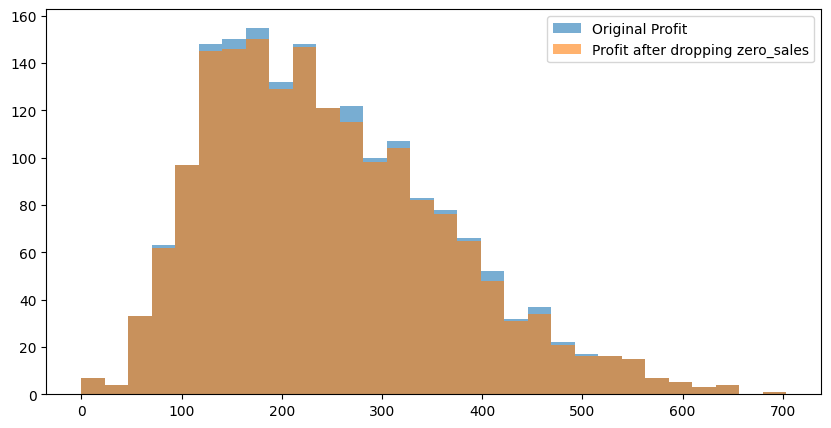

In [51]:
# Visual representation of data before and after dropping rows
fig, axes = plt.subplots( figsize=(10,5))

# Histogram before dropping zero_sale rows
axes.hist(df['Profit'], bins=30, alpha=0.6, label="Original Profit")
# axes[0].set_title("Profit including zero_sales rows")

# Profit histogram after dropping zero_Sale rows
axes.hist(clear_df['Profit'], bins=30, alpha=0.6, label="Profit after dropping zero_sales")
# axes[1].set_title("Profit with non-zero sale rows")

# plt.tight_layout()
plt.legend()
plt.show()

Our data is in clean state now. Thus, we are moving toward fetching patterns in dataset.

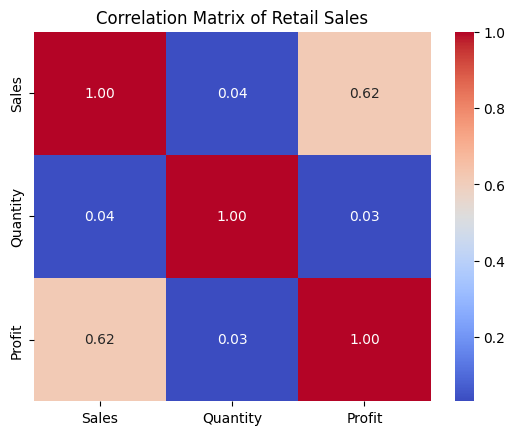

In [52]:
# Plotting a heatmap to show correlation among variables
num_df= clear_df[[ 'Sales', 'Quantity', 'Profit']]
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Retail Sales")
plt.show()

The correlation matrix of retail-sales shows that 'Sales' and 'Profit' have moderately positive correlation, which makes sense. Quantity has a near-zero correlation of 0.04 with Sales and 0.03 with Profit. This indicates that total revenue is driven more by product price and category mix than by the number of units sold.

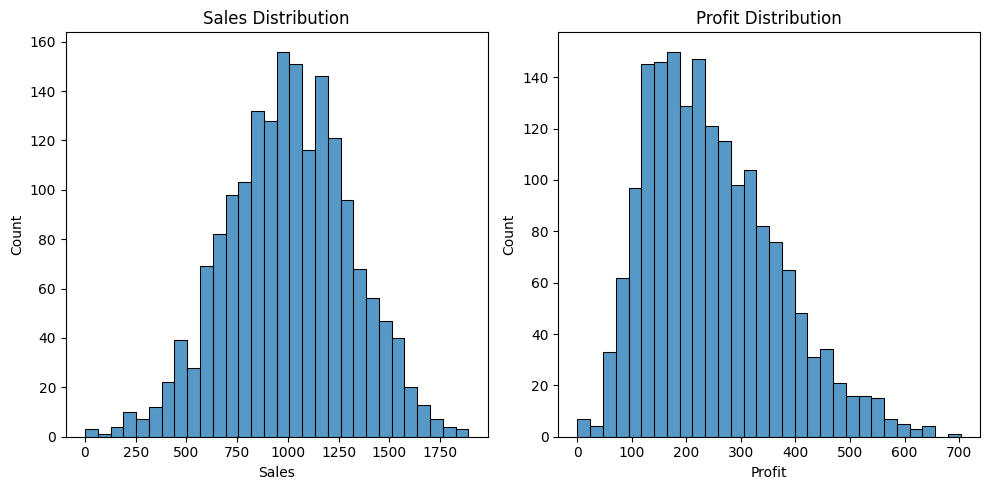

In [53]:
# Sales and Profit Distribution
fig, axe = plt.subplots(1,2, figsize=(10, 5))

# Sales Distribution
sns.histplot(clear_df['Sales'], ax=axe[0], bins=30)
axe[0].set_title("Sales Distribution")

# Profit Trend
sns.histplot(clear_df['Profit'], ax=axe[1], bins=30)
axe[1].set_title("Profit Distribution")

plt.tight_layout()
plt.show()

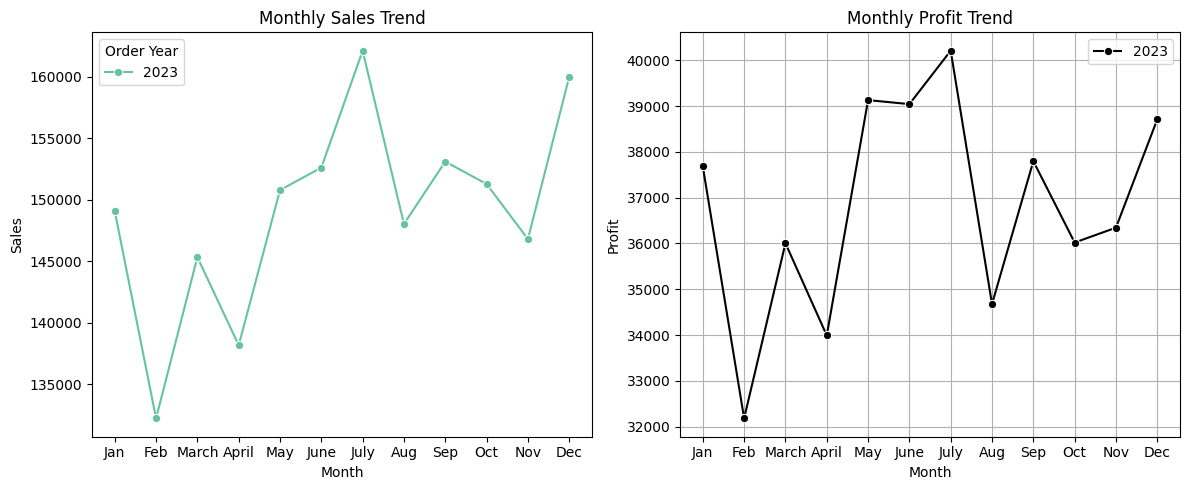

In [54]:
# Monthly Sale and Profit Trends
groupby_year_month = clear_df.groupby(['Order Year', 'Order Month'])
monthly_sale_profit = groupby_year_month[['Sales', 'Profit']].sum().reset_index()

# Monthly Sale Trend
fig, axe = plt.subplots(1,2, figsize=(12,5))
sns.lineplot(ax=axe[0], data=monthly_sale_profit, x='Order Month', y='Sales', hue='Order Year', marker='o', palette='Set2' )
axe[0].set_title("Monthly Sales Trend")
axe[0].set_xlabel("Month")
axe[0].set_ylabel("Sales")
axe[0].set_xticks(range(1,13), labels=['Jan', 'Feb', 'March', 'April', 'May', 'June', 'July',
                                 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Monthly Profit Trend
sns.lineplot(ax=axe[1], data=monthly_sale_profit, x='Order Month', y='Profit', hue='Order Year', marker='o', palette="magma" )
axe[1].set_title("Monthly Profit Trend")
axe[1].set_xlabel("Month")
axe[1].set_ylabel("Profit")
axe[1].set_xticks(range(1,13), labels=['Jan', 'Feb', 'March', 'April', 'May', 'June', 'July',
                                 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.legend()
plt.grid(True)
plt.tight_layout()


The 'Sales Trend' line plot shows an upward trend from January to December. It tells us about higher demand during certain months, possibly due to holiday seasons, festive occasions or annual sales events. 
The 'Profit Trend' line plot is almost same as 'Sales Trend'. But the higher profit rates irrespective of lower sales indicate that high profit margin items are sold in those months. 

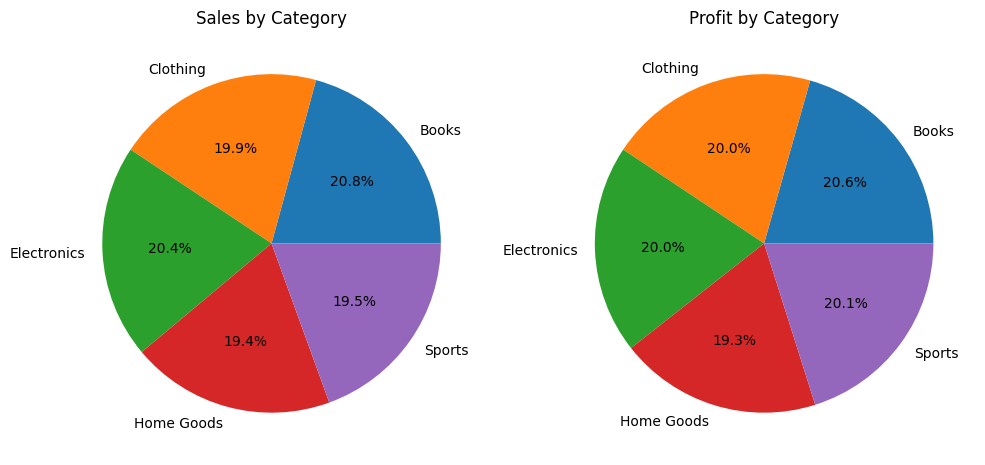

In [55]:
# Sale and Profit by Category
by_category = clear_df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

fig, axe = plt.subplots(1,2, figsize=(10,5))
axe[0].pie(by_category['Sales'], labels=by_category['Category'], autopct='%1.1f%%')
axe[0].set_title("Sales by Category")

axe[1].pie(by_category['Profit'], labels=by_category['Category'], autopct="%1.1f%%")
axe[1].set_title("Profit by Category")

plt.tight_layout()

These pie charts show that each category contributes in profit, almost equally.

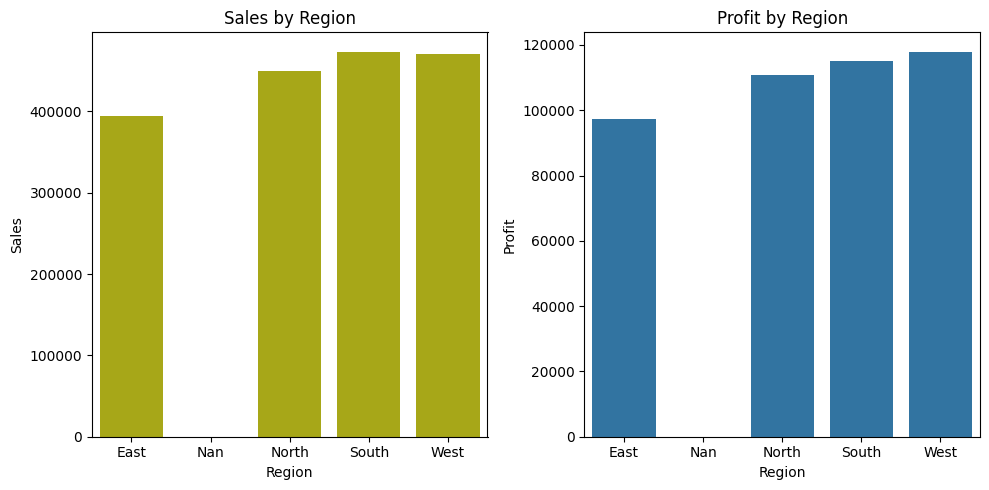

In [56]:
#  Sales and Profit by Region
by_region = clear_df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

fig, axe = plt.subplots(1,2, figsize=(10, 5))
sns.barplot(ax=axe[0], data=by_region, x='Region', y='Sales', color='y', estimator=sum)
axe[0].set_title("Sales by Region")

sns.barplot(ax=axe[1], data=by_region, x='Region', y='Profit')
axe[1].set_title("Profit by Region")

plt.tight_layout()


__Summary__: <br>
  In this data analysis project, we explored dataset of Retail-Sales. We dealt with 1825 rows and 6 columns. We performed Exploratory Data Analysis(EDA) to gain data insights. Firstly, we handled 'Date', 'Category' and 'Region' columns for better manipulation. Then, missing values and zero sales were managed. For better data understanding, we analyzed correlation among variables, patterns of sales and profit, and their trend by category. <br>
Throughout the project, important insights are:
- Correlation matrix showed how correlated the variables are to each other. Sales and Profit showed moderately positive correlation of 0.62. While other correlations were near-zero, means no significant relation between them.<br>
- Upward trend in sales and profit throughout the year with drops during April and November. <br>
- Each category contributes equally to profit as illustrated by pie graphs. <br>
- Sales and profit by region trends show that South region has high sales. While West region gives high profit, probably due to class difference.<br>
Overall, 'Sales and Profit Analysis' on retail sales data provides valuable insights into performance and profitablity. Through these insights, guided strategic decisions, better resource management and marketing strategy can be achieved. Thus, the project highly emphasizes data analysis power towards business understanding and mainly, better business decisions.